# Military Strikes Forecasting

Generate a forecasting dataset about global military strikes and attack operations using the LightningRod SDK. Fine-tune a model via RL that outperforms frontier LLMs on strike prediction.

In [16]:
%pip install lightningrod-ai python-dotenv pandas

from IPython.display import clear_output
clear_output()

from datetime import datetime

import pandas as pd
from dotenv import load_dotenv

load_dotenv()

True

## Set up the client

Sign up at [dashboard.lightningrod.ai](https://dashboard.lightningrod.ai/sign-up?redirect=/api) to get your API key and **$50 of free credits**.

In [17]:
from lightningrod import LightningRod
from lightningrod.utils import config

api_key = config.get_config_value("LIGHTNINGROD_API_KEY")
lr = LightningRod(api_key=api_key)

## Build the pipeline

Configure the pipeline with domain-specific instructions and examples for military strike forecasting. Covers airstrikes, missile strikes, drone strikes, and naval strikes across state and non-state actors globally.

In [18]:
instructions = """
Generate binary forecasting questions specifically about military strikes and attack operations.

Cover all strike types:
- Airstrikes (fighter jets, bombers, helicopter gunships)
- Missile strikes (ballistic, cruise, hypersonic)
- Drone strikes (kamikaze drones, armed UAVs, drone swarms)
- Naval strikes (ship-launched missiles, naval gunfire, submarine attacks)

Cover both state and non-state actors. Use the natural language of news reporting:
- State actors: country names, leader names, named military units (IDF, IRGC, Pentagon)
- Non-state actors: group names (Hamas, Houthis, Hezbollah, ISIS, Wagner)

Questions must:
- Name the specific actor conducting the strike
- Name the specific target (location, infrastructure, military asset, or group)
- Have a specific date or event milestone as resolution criteria
- Be objectively verifiable from open-source news
- Span the full probability spectrum \u2014 some likely, some unlikely, some that won't happen
"""

good_examples = [
    "Will the IDF conduct airstrikes on Hezbollah weapons depots in the Bekaa Valley before November 2024?",
    "Will US Air Force B-52s conduct strikes on Houthi military infrastructure in Yemen before March 2024?",
    "Will Russian Su-34s carry out airstrikes on Kharkiv civilian infrastructure before June 2024?",
    "Will Iran launch a direct ballistic missile strike on Israeli territory before May 2024?",
    "Will Houthi forces fire anti-ship missiles at US Navy destroyers in the Red Sea before February 2024?",
    "Will Ukraine conduct drone strikes on Russian oil refineries inside Russian territory before April 2024?",
    "Will North Korea launch an ICBM test over Japanese waters before January 2024?",
    "Will Houthi forces attack a commercial vessel with drone boats in the Red Sea before March 2024?",
    "Will the US Navy conduct ship-launched Tomahawk strikes on Houthi radar sites before February 2024?",
    "Will Russian forces launch an armored offensive toward Chasiv Yar before April 2024?",
    "Will Israel conduct airstrikes on Iranian nuclear facilities at Natanz before December 2024?",
    "Will NATO aircraft conduct strikes inside Russian territory before January 2025?",
    "Will China conduct missile strikes on Taiwanese military bases before the end of 2024?",
    "Will Pakistan conduct airstrikes on Afghan Taliban positions before March 2024?",
]

bad_examples = [
    "Will there be an attack somewhere? (no specific actor, target, or location)",
    "Will violence increase in the Middle East? (vague, not a specific strike event)",
    "Will conflict continue in Ukraine? (trivially obvious, not a specific strike)",
    "Will missiles be fired? (no actor, no target, no date)",
    "Will tensions escalate? (not a verifiable strike event)",
    "Will there be drone activity near the border? (too vague to verify)",
    "Will the situation get worse? (subjective, not measurable)",
    "Will airstrikes happen in 2025? (no actor, no target, too broad)",
    "Will someone retaliate? (no specific actor or method)",
    "Will the war end? (not a strike event, different question type)",
]

search_queries = [
    "military airstrike",
    "military strike",
    "missile strike",
    "drone strike",
    "naval strike",
]

In [19]:
from lightningrod import (
    BinaryAnswerType,
    NewsSeedGenerator,
    ForwardLookingQuestionGenerator,
    NewsContextGenerator,
    WebSearchLabeler,
    QuestionPipeline,
)

answer_type = BinaryAnswerType()

pipeline = QuestionPipeline(
    seed_generator=NewsSeedGenerator(
        start_date=datetime(2024, 6, 1),
        end_date=datetime(2026, 3, 1),
        interval_duration_days=7,
        search_query=search_queries,
        articles_per_search=10,
    ),
    question_generator=ForwardLookingQuestionGenerator(
        instructions=instructions,
        examples=good_examples,
        bad_examples=bad_examples,
        answer_type=answer_type,
        questions_per_seed=5,
    ),
    context_generators=[
        NewsContextGenerator(
            articles_per_query=3,
            num_search_queries=3,
            num_articles=5,
        )
    ],
    labeler=WebSearchLabeler(answer_type=answer_type),
)

## Run the pipeline

Collect news articles, generate questions, and label answers. Set `max_questions=10000` for a full production run; reduce for testing.

In [ ]:
dataset = lr.transforms.run(pipeline, max_questions=10000, name="Military strikes forecasting")

samples = dataset.download()
pct = (sum(1 for s in samples if s.is_valid is True) / len(samples) * 100) if samples else 0
print(f"{len(samples)} samples ({pct:.1f}% valid)")

## Prepare the dataset

Filter valid samples, deduplicate, and split into train/test sets using a temporal strategy.

In [ ]:
from lightningrod import filter_and_split

train_dataset, test_dataset = filter_and_split(
    dataset,
    test_size=0.2,
    split_strategy="temporal",
    days_to_resolution_range=(1, 90),
)

for name, ds in [("Train", train_dataset), ("Test", test_dataset)]:
    data = ds.flattened()
    yes_count = sum(1 for s in data if s.get("label") in (1, "1", 1.0))
    print(f"{name}: {len(data)} rows, {yes_count/len(data)*100:.1f}% yes")

Train: 3578 rows, 50.0% yes
Test: 993 rows, 60.8% yes


## Train the model

Fine-tune `openai/gpt-oss-120b` via RL using the training parameters from our golf and WWTD experiments.

In [ ]:
from lightningrod import TrainingConfig
BATCH_SIZE = 32                                                                                                                           

train_data = train_dataset.flattened()                                                                                                    
training_steps = max(10, len(train_data) // BATCH_SIZE)

training_config = TrainingConfig(
    base_model="openai/gpt-oss-120b",
    training_steps=training_steps,
    lora_rank=32,
    batch_size=BATCH_SIZE,
    num_rollouts=8,
    max_response_length=16384,
    learning_rate=4e-5,
)

cost_estimate = lr.training.estimate_cost(training_config, dataset=train_dataset)
print(f"Estimated cost: ${cost_estimate.total_cost_dollars:.2f}")
print(f"Effective steps: {cost_estimate.effective_steps}")
print(f"Train tokens: {cost_estimate.train_tokens:,}")
if cost_estimate.notes:
    print(f"Notes: {cost_estimate.notes}")

In [ ]:
job = lr.training.run(training_config, dataset=train_dataset, name="military-strikes-v1")
print(f"Job {job.id} completed with status: {job.status}")
print(f"Model ID: {job.model_id}")

## Evaluate

Run the trained model against the test set, benchmarked against GPT-5.1.

In [ ]:
eval_job = lr.evals.run(
    model_id=job.model_id,
    dataset=test_dataset,
    benchmark_model_id="openai/gpt-5.4",
)

print(f"Eval completed: {eval_job.id}")
if eval_job.metrics:
    print(eval_job.metrics)

In [ ]:
# Quick inference test
print(lr.predict(job.model_id, "Will Israel conduct airstrikes in southern Lebanon before April 2026?"))

## Direct Tinker Evaluation (step 50 checkpoint)

Training crashed at step 52 but saved a checkpoint at step 50. Run inference directly via the Tinker SDK, bypassing the LR eval API.

In [1]:
from pathlib import Path
from dotenv import load_dotenv
load_dotenv(Path().resolve() / ".env", override=True)

import os
import pandas as pd
from lightningrod import LightningRod, filter_and_split

lr = LightningRod(api_key=os.environ["LIGHTNINGROD_API_KEY"])

dataset = lr.datasets.get("8841b3cb-35c5-496f-a217-a3ec50f0bdca")
_ = dataset.download()

_, test_dataset = filter_and_split(
    dataset,
    test_size=0.2,
    split_strategy="temporal",
    days_to_resolution_range=(1, 90),
)
print(f"Test: {len(test_dataset.samples())} samples")
print(f"TINKER_API_KEY set: {bool(os.environ.get("TINKER_API_KEY"))}")

Test: 993 samples
TINKER_API_KEY set: True


In [2]:
import sys, os, types

sys.path.insert(0, os.path.expanduser("~/dev/llm_forecasting"))

# Bypass GCP secrets import — we have TINKER_API_KEY in .env
secrets_mod = types.ModuleType("lightningrodlabs.utils.secrets_env")
secrets_mod.TINKER_API_KEY = lambda: os.environ["TINKER_API_KEY"]
sys.modules["lightningrodlabs.utils.secrets_env"] = secrets_mod

from lightningrod._generated.models.binary_answer_type import BinaryAnswerType as _BinaryAnswerType
from lightningrod.training.samples import to_training_record
from lightningrodlabs.v2.inference.tinker_inference import run_tinker_inference
from lightningrodlabs.v2.analysis.analysis_runner import Analysis

CHECKPOINT = "tinker://f47221df-706a-57a3-bfb0-e7ee179c804a:train:0/sampler_weights/step_0050"
BASE_MODEL = "openai/gpt-oss-120b"

# Render test samples into the format Tinker expects
test_rows = [to_training_record(s, answer_type=_BinaryAnswerType()) for s in test_dataset.samples()]
print(f"Test rows: {len(test_rows)}")

/Users/benjaminturtel/dev/lightningrod-python-sdk/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Test rows: 993


In [5]:
# Run RL-trained, base, and GPT-5.4 benchmark — all in parallel
import asyncio
import re
from tqdm import tqdm

BENCHMARK_MODEL = "openai/gpt-5.4"

def parse_answer(output):
    m = re.search(r"<answer>(.*?)</answer>", output or "", re.DOTALL)
    if m:
        try: return float(m.group(1).strip())
        except ValueError: return None
    return None

def run_benchmark(rows, model):
    results = []
    for row in tqdm(rows, desc=f"Inference ({model})"):
        prompt = row["prompt"][0]["content"]
        try:
            output = lr.predict(model, prompt)
        except Exception as e:
            output = f"ERROR: {e}"
        parsed = parse_answer(output)
        reward = -((parsed - row["correct_answer"]) ** 2) if parsed is not None else -1.0
        results.append({"output": output, "reward": reward, "parsed_answer": parsed, "row": row})
    return results

async def run_all():
    # Launch both Tinker inferences + GPT-5.4 benchmark concurrently
    tinker_configs = [
        ("gpt-oss-120b RL (step 50)", CHECKPOINT),
        ("gpt-oss-120b (base)", None),
    ]
    tinker_tasks = [
        run_tinker_inference(ckpt, test_rows, base_model=BASE_MODEL, api_key=os.environ["TINKER_API_KEY"])
        for _, ckpt in tinker_configs
    ]

    loop = asyncio.get_event_loop()
    bench_future = loop.run_in_executor(None, run_benchmark, test_rows, BENCHMARK_MODEL)

    # All three run concurrently
    *tinker_results, bench_results = await asyncio.gather(*tinker_tasks, bench_future)

    all_results = []
    for (name, _), results in zip(tinker_configs, tinker_results):
        metrics = Analysis.compute_metrics_from_results(results)
        all_results.append({"name": name, **metrics.__dict__})
        print(f"{name} — Brier: {metrics.brier_score:.4f}, ECE: {metrics.ece:.4f}")

    bench_metrics = Analysis.compute_metrics_from_results(bench_results)
    all_results.append({"name": BENCHMARK_MODEL, **bench_metrics.__dict__})
    print(f"{BENCHMARK_MODEL} — Brier: {bench_metrics.brier_score:.4f}, ECE: {bench_metrics.ece:.4f}")

    return all_results

all_results = await run_all()
pd.DataFrame(all_results)[["name", "brier_score", "ece"]].round(4)

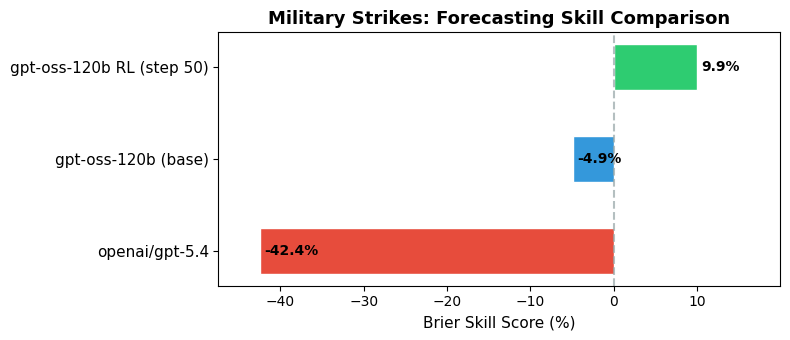

In [6]:
# Brier Skill Score comparison
import matplotlib.pyplot as plt

def bss(brier):
    return (1 - brier / 0.25) * 100

for r in all_results:
    r["brier_skill_score"] = bss(r["brier_score"])

names = [r["name"] for r in all_results]
bss_vals = [r["brier_skill_score"] for r in all_results]
colors = ["#2ecc71" if "RL" in n else "#e74c3c" if "gpt-5" in n.lower() else "#3498db" for n in names]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(range(len(names)), bss_vals, color=colors, edgecolor="white", height=0.5)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=11)
ax.set_xlabel("Brier Skill Score (%)", fontsize=11)
ax.set_title("Military Strikes: Forecasting Skill Comparison", fontsize=13, fontweight="bold")
for bar, val in zip(bars, bss_vals):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.axvline(x=0, color="#95a5a6", linestyle="--", lw=1.5, alpha=0.7)
ax.set_xlim(min(min(bss_vals) - 5, -5), max(bss_vals) + 10)
ax.invert_yaxis()
plt.tight_layout()